# Neural Networks (MLP) for Regression

__INDEX__
1. [Neural Networks (MLPs)](#neuralnet) <br>
    1.1. [About Neural Networks(MLPs)](#about) <br>
    1.2. [MLPRegressor in Scikit-learn](#scikit)<br>
    1.3. [Why We Use MLPs in This Project](#project)<br>
    1.4. [Limitations](#limitations)<br>

2. [Setup and Data Preparation](#setup)
3. [Experimental Runs](#expruns)<br>
    3.1. [Baseline Model (Preprocessed Data Only)](#baseline) <br>
    3.2. [Baseline Model using feature selection](#baselinefs) <br>
    3.3. [Impact of Removing Previous Owners in Feature-Selected Baseline](#noprevious)<br>
    3.4. [Feature Engineering Without Feature Selection](#fe_nofs)<br>
    3.5. [Model Performance with Log-Target, Age Feature, and Feature Selection](#log_age)<br>
    3.6. [Model with Feature Engineering and Feature Selection](#fe_fs)<br>
4. [Final Configuration](#finalconfig)
5. [Visualization and Final Regards about the Implementation](#visualization)

## 1. Neural Networks (MLPs)
<a id="neuralnet"></a>

### 1.1. About Neural Networks(MLPs)
<a id="about"></a>

Neural networks, more specifically Multi-Layer Perceptrons (MLPs), are flexible models that learn complex relationships by combining multiple non-linear transformations across connected layers. Instead of relying on tree structures or rule-based splits, MLPs model the relationship between input features and the target variable by learning a set of weights optimized jointly.

In the context of our car price prediction task, this is particularly relevant, since the relationship between variables such as brand, model, mileage, age, engine size, and fuel type is highly non-linear and involves multiple interactions. MLPs allow us to explore whether these interactions can be captured more effectively by a high-capacity model.

Training an MLP can be seen as an optimization problem: the model minimizes a loss function by iteratively updating its weights through backpropagation. Unlike boosting algorithms, which sequentially correct residual errors, MLPs adjust all parameters simultaneously to reduce the overall prediction error.

### 1.2. MLPRegressor in Scikit-learn
<a id="scikit"></a>

Scikit-learn provides an implementation of feed-forward neural networks for regression through MLPRegressor, which we use in this project. This implementation allows us to control:

- the network architecture (number of hidden layers and neurons);
- the learning rate and batch size;
- the optimization solver (Adam);
- early stopping to reduce overfitting.

Contrary to tree-based models used earlier in this project, MLPs do not natively support missing values or categorical features. For this reason, we apply a full preprocessing pipeline before training the model, including imputations, categorical resolvers, target encoding, one-hot encoding, and feature scaling. This ensures that the neural network receives well-conditioned numerical inputs.

Given the sensitivity of neural networks to hyperparameters, we rely on Random Search combined with K-Fold cross-validation to evaluate different configurations and assess their robustness across folds.

### 1.3 Why We Use MLPs in This Project
<a id="project"></a>

We include MLPs in our experimental setup to complement tree-based approaches and to evaluate how a fully non-linear, high-capacity model performs on our dataset. By using hidden layers, the model can learn interactions between features that may not be explicitly captured by linear models or shallow trees.

Although neural networks require more careful preprocessing and tuning, they provide a useful comparison point and help us understand whether additional modeling flexibility leads to improved price predictions in our setting.

### 1.4. Limitations
<a id="limitations"></a>
Neural networks take longer to train, are sensitive to scaling, and may overfit if the architecture is too large or if early stopping is not used.

## 2. Setup and Preparation
<a id="setup"></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
import time
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import os
import random
import logging
from IPython.display import display

In [3]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) - np.asarray(y_pred)))

def get_random_configs(n_iter: int):
    configs = []
    keys = list(param_distributions.keys())

    for i in range(n_iter):
        params = {k: random.choice(list(param_distributions[k])) for k in keys}

        name = (
            f"R{i}"
            f"_n{params['n_estimators']}"
            f"_ms{params['max_samples']}"
            f"_mf{params['max_features']}"
            f"_d{params['tree_max_depth']}"
            f"_leaf{params['tree_min_samples_leaf']}"
            f"_split{params['tree_min_samples_split']}"
        )

        configs.append((name, params))

    return configs


In [4]:
%run 05_0.1_visualization_helpers.ipynb  

In [5]:
# All of our preprocessing helper functions are in this notebook
%run 05_0_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# at this point, this are all the features in use 
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']              
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 8 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness
# ---------------------------------------------------------
# 0) CONFIGS GERAIS
# ---------------------------------------------------------
N_SPLITS = 8
N_ITER = 10
RANDOM_STATE = 42


X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 3. Experimental Runs
<a id="expruns"></a>

### 3.1 Baseline Model (Preprocessed Data Only) - 1
<a id="baseline"></a>

adicionar scaling 

In [6]:
# we will use an 5-fold cross-validation strategy
N_SPLITS = 5 
RANDOM_STATE = 42
# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

N_RANDOM_CONFIGS = 10 # this is a short random search, enough for baseline results

# we get N_RANDOM_CONFIGS (10) random parameter combinations from param_distributions 
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE 
best_rmse = np.inf 
best_config = None 

# to store our fold results
log_path = "NN_2complete_log.txt"
# Note: this section is mainly for organizational purposes and is not particularly relevant 


with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    # header for the log file - just for readability and general info
    log("# =============================")
    log(f"# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########") 
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")


            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, "mileage", True)
            X_train = transform_mileage_imputer(X_train, mileage_state)
            X_val   = transform_mileage_imputer(X_val,   mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)


            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"] # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train) # fit on training data
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features]) # fit on training data
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            #-------
            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            #----------------
            # here, we log the features name, to keep track of what is being used from the original set
            # but also because the columns increase due to encoding
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            
            # -> Model Training 
            # params contains the hyperparameters for this configuration
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_final, y_train)

            # predictions on train and validation fold
            y_pred_train = mlp_model.predict(X_train_final)
            y_pred_val   = mlp_model.predict(X_val_final)

            # -> Metrics Calculation
            # Training metrics:
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")
            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")


# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(10))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: NN_2complete_log.txt
# =============================

######## CONFIG 1/10 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}

[C1|F1] Processing fold...
  > Features Used (16): ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9320 | RMSE: 2552 | MAE: 1591 | Bias: 156.7
  > [VAL]   R2: 0.9240 | RMSE: 2631 | MAE: 1661 | Bias: 100.3

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9282 | RMSE: 2609 | MAE: 1620 | Bias: -42.4
  > [VAL]   R2: 0.9175 | RMSE: 2793 | MAE: 1693 | Bias:

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
9,10,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu,2668.127307,1615.822371,0.924866,-86.336797,1517.622022,0.939983,-91.676814,1059.941917
2,3,adam,25,900,0.050,adaptive,"(256, 128)",True,64,relu,2687.640832,1610.776651,0.923739,56.962121,1506.363123,0.940348,51.364284,1038.633840
6,7,adam,25,900,0.010,adaptive,"(256, 128)",True,64,relu,2689.598630,1609.053568,0.923602,77.357832,1499.378927,0.939936,74.041834,1035.001909
5,6,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,2712.272013,1622.566772,0.922321,-28.796049,1529.865517,0.936701,-31.789218,1052.886451
1,2,adam,25,900,0.050,adaptive,"(128, 64)",True,128,relu,2743.890304,1638.534894,0.920427,136.493544,1542.596185,0.936727,127.116751,1055.691609
3,4,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,2750.515480,1642.173124,0.920143,-30.469929,1560.237195,0.933732,-30.032407,1072.413753
4,5,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,2764.331106,1667.714513,0.919310,-56.365075,1600.137564,0.931068,-57.384209,1098.068212
8,9,adam,25,900,0.010,adaptive,"(128, 64)",True,64,relu,2772.163645,1662.307758,0.918841,75.919367,1593.081374,0.931062,71.298782,1077.477668
7,8,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,2778.988765,1666.748844,0.918423,35.305856,1607.065674,0.929312,36.664789,1088.370963
0,1,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu,2781.756918,1668.791638,0.918321,-55.335113,1597.582258,0.930757,-47.390189,1095.288779



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}


### 3.2. Baseline Model using feature selection - opcional
<a id="baselinefs"></a>

### 3.3. Impact of Removing Previous Owners e log do preço no fs -2
<a id="noprevious"></a>

In [ ]:
# we will use an 5-fold cross-validation strategy
N_SPLITS = 5 
RANDOM_STATE = 42
# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "year"]
DROP_FROM_MODEL = ["previousOwners"]
# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

N_RANDOM_CONFIGS = 10 # this is a short random search, enough for baseline results

# we get N_RANDOM_CONFIGS (10) random parameter combinations from param_distributions 
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE 
best_rmse = np.inf 
best_config = None 

# to store our fold results
log_path = "NN_noowners_logprice.txt"
# Note: this section is mainly for organizational purposes and is not particularly relevant 


with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    # header for the log file - just for readability and general info
    log("# =============================")
    log(f"# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########") 
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
            y_train_log = np.log1p(y_train)
            log(f"\n[C{config_id}|F{fold}] Processing fold...")


            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, "mileage", True)
            X_train = transform_mileage_imputer(X_train, mileage_state)
            X_val   = transform_mileage_imputer(X_val,   mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"] # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log) # fit on training data
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features]) # fit on training data
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)


            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model Training 
            # params contains the hyperparameters for this configuration
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_final, y_train_log)

            # predictions on train and validation fold
            y_pred_train_log = mlp_model.predict(X_train_final)
            y_pred_val_log   = mlp_model.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics Calculation
            # Training metrics:
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")
            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")


# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(10))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: NN_noowners_logprice.txt
# =============================

######## CONFIG 1/10 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'year', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9141 | RMSE: 2867 | MAE: 1712 | Bias: 79.8
  > [VAL]   R2: 0.9166 | RMSE: 2755 | MAE: 1730 | Bias: 33.8

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9106 | RMSE: 2912 | MAE: 1707 | Bias: 119.2
  > [VAL]   R2: 0.9053 | RMSE: 2993 | MAE: 1753 | Bias: 139.2

[C1|F3] 

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
5,6,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,2.955609e+03,1748.665946,9.077264e-01,-36.420291,1718.875297,9.123759e-01,-42.238033,1126.215791
0,1,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu,2.990074e+03,1758.130099,9.055593e-01,27.654105,1719.427977,9.127058e-01,25.130324,1119.766822
4,5,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,3.022066e+03,1785.436068,9.034372e-01,41.589732,1751.934563,9.088124e-01,37.637949,1127.121193
6,7,adam,25,900,0.010,adaptive,"(256, 128)",True,64,relu,3.034206e+03,1783.536947,9.028115e-01,88.244625,1751.221860,9.094600e-01,78.150063,1130.481610
3,4,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,3.064994e+03,1789.782465,9.006964e-01,315.919010,1759.685018,9.057782e-01,317.356445,1126.639536
7,8,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,3.074014e+03,1722.966561,8.998630e-01,182.895664,1680.268946,9.126809e-01,176.345930,1079.450972
9,10,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu,3.577240e+03,1806.815598,8.481795e-01,99.104081,1774.120240,8.763857e-01,95.178913,1102.876655
1,2,adam,25,900,0.050,adaptive,"(128, 64)",True,128,relu,3.932983e+03,2225.192939,8.257119e-01,151.017798,2205.765916,7.768405e-01,152.324136,1443.692238
2,3,adam,25,900,0.050,adaptive,"(256, 128)",True,64,relu,4.845087e+03,3011.155283,6.820970e-01,861.947340,2984.988892,6.853766e-01,851.557880,2037.717130
8,9,adam,25,900,0.010,adaptive,"(128, 64)",True,64,relu,6.640901e+06,55638.197243,-2.182925e+06,-53706.847242,44568.036233,-2.264859e+06,-42668.026365,1120.471057



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'activation': 'relu'}


###  3.5. Model Performance with Log-Target, Age Feature, without Feature Selection (No Previous Owners) - 3
<a id="log_age"></a>

In [ ]:
# we will use an 5-fold cross-validation strategy
N_SPLITS = 5 
RANDOM_STATE = 42
# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]
DROP_FROM_MODEL = ["previousOwners"]
# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

N_RANDOM_CONFIGS = 10 # this is a short random search, enough for baseline results

# we get N_RANDOM_CONFIGS (10) random parameter combinations from param_distributions 
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE 
best_rmse = np.inf 
best_config = None 

# to store our fold results
log_path = "NN_noowners_age_logprice.txt"
# Note: this section is mainly for organizational purposes and is not particularly relevant 


with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    # header for the log file - just for readability and general info
    log("# =============================")
    log(f"# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########") 
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
            y_train_log = np.log1p(y_train)
            log(f"\n[C{config_id}|F{fold}] Processing fold...")


            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, "mileage", True)
            X_train = transform_mileage_imputer(X_train, mileage_state)
            X_val   = transform_mileage_imputer(X_val,   mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

             # -> Feature engineering: create age and drop year (do this after all year-based steps)
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # hard guarantee: previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"] # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log) # fit on training data
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features]) # fit on training data
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            ###
            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            ####
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model Training 
            # params contains the hyperparameters for this configuration
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_final, y_train_log)

            # predictions on train and validation fold
            y_pred_train_log = mlp_model.predict(X_train_final)
            y_pred_val_log   = mlp_model.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics Calculation
            # Training metrics:
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")
            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")


# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(10))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: NN_noowners_age_logprice.txt
# =============================

######## CONFIG 1/10 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9139 | RMSE: 2871 | MAE: 1713 | Bias: 404.8
  > [VAL]   R2: 0.9163 | RMSE: 2762 | MAE: 1743 | Bias: 362.2

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9058 | RMSE: 2990 | MAE: 1745 | Bias: 348.6
  > [VAL]   R2: 0.9014 | RMSE: 3054 | MAE: 1786 | Bias: 378.2

[C1

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
7,8,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,2928.273188,1716.228911,0.909464,39.355923,1673.107657,0.916802,31.946904,1089.886092
9,10,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu,2994.776836,1729.015973,0.905280,368.232619,1691.439998,0.912918,367.702438,1078.196528
5,6,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,3007.872502,1746.999522,0.904503,235.739317,1719.372751,0.909701,231.236865,1105.059387
6,7,adam,25,900,0.010,adaptive,"(256, 128)",True,64,relu,3027.936760,1779.526294,0.903207,278.616410,1754.374909,0.908253,268.639172,1109.531912
8,9,adam,25,900,0.010,adaptive,"(128, 64)",True,64,relu,3052.360412,1783.887459,0.901541,207.956691,1755.932637,0.907709,209.571707,1123.133106
0,1,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu,3087.820937,1788.078115,0.899215,357.557668,1757.879815,0.906467,355.448900,1123.953734
3,4,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,3248.124270,1781.338499,0.887231,116.850248,1742.701962,0.902604,112.667304,1133.447822
1,2,adam,25,900,0.050,adaptive,"(128, 64)",True,128,relu,3259.342532,1914.091665,0.887779,510.874370,1896.834295,0.892251,498.051456,1211.406965
4,5,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,3453.640048,1770.935085,0.864431,-11.743333,1733.924881,0.878490,-19.942061,1116.604309
2,3,adam,25,900,0.050,adaptive,"(256, 128)",True,64,relu,6150.974097,3984.462806,0.499367,975.064051,3943.689567,0.503156,946.017394,2800.029722



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}


###  3.5. Model Performance with Log-Target, Age Feature, with Feature Selection (No Previous Owners) - 4

In [ ]:
# numeric features used by the model (year is replaced by age; previousOwners is excluded)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]



# shuffles the data, in order to (at least theoretically) have more balanced folds
# we will use an 8-fold cross-validation strategy
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we explicitly exclude this feature from the model input
DROP_FROM_MODEL = ["previousOwners"]

# feature selection: keep 90% of the final encoded feature space
FS_KEEP_RATIO = 0.80

# RandomForest used only to rank feature importances for SelectFromModel
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}


N_RANDOM_CONFIGS = 15  # short random search, enough for baseline results

# we get N_RANDOM_CONFIGS random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # stores results for ranking
best_rmse = np.inf
best_config = None

# log setup (mainly for development and traceability)
log_path = "NN_noowners_age_log_fs.txt"

# Note: this section is included mainly for organizational purposes
with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF NN SEARCH (LOG TARGET + AGE FEATURE + FS 80%)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []
        fold_nsel = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-transform target for training
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing steps (fit only on training fold, apply to both)
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # -> Feature engineering: create age and drop year (do this after all year-based steps)
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # hard guarantee: previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature encoding (categorical only)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # fit using log-target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            #-------
            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            #----------------
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features before FS ({len(feature_names)}): {feature_names}")

            # -> Feature selection (keep top 90% features by RF importance)
            n_feats = X_train_final.shape[1]
            k = int(np.ceil(FS_KEEP_RATIO * n_feats))
            k = max(1, min(k, n_feats))

            rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
            rf_fs.fit(X_train_final, y_train_log)

            selector = SelectFromModel(
                estimator=rf_fs,
                threshold=-np.inf,  # keep the top max_features
                max_features=k,
                prefit=True
            )

            selected_cols = X_train_final.columns[selector.get_support()]
            fold_nsel.append(len(selected_cols))

            X_train_sel = X_train_final[selected_cols]
            X_val_sel   = X_val_final[selected_cols]

            if fold == 1:
                log(f"  > Selected features ({len(selected_cols)}/{n_feats}) with FS_KEEP_RATIO={FS_KEEP_RATIO:.2f}")

            # -> Model training (train on log-target)
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_sel, y_train_log)

            # predictions (log scale), then invert to original scale
            y_pred_train_log = mlp_model.predict(X_train_sel)
            y_pred_val_log   = mlp_model.predict(X_val_sel)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics on original scale
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)

            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        mean_nsel = float(np.mean(fold_nsel))

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  Selected features (avg): {mean_nsel:.0f} / {n_feats} (after encoding)")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "fs_keep_ratio": FS_KEEP_RATIO,
            "avg_selected_features": mean_nsel,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(5))

print("\nBest Config found:")
print(best_config)


# =============================
# START OF NN SEARCH (LOG TARGET + AGE FEATURE + FS 80%)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: NN_noowners_age_log_fs.txt
# =============================

######## CONFIG 1/15 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.05, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'activation': 'relu'}

[C1|F1] Processing fold...


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  > Features before FS (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > Selected features (12/15) with FS_KEEP_RATIO=0.80
  > [TRAIN] R2: 0.8700 | RMSE: 3522 | MAE: 2101 | Bias: 506.6
  > [VAL]   R2: 0.8754 | RMSE: 3358 | MAE: 2105 | Bias: 482.0

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.8726 | RMSE: 3478 | MAE: 2126 | Bias: 369.9
  > [VAL]   R2: 0.8769 | RMSE: 3399 | MAE: 2141 | Bias: 293.1

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.8727 | RMSE: 3476 | MAE: 2094 | Bias: 261.5
  > [VAL]   R2: 0.8738 | RMSE: 3442 | MAE: 2070 | Bias: 294.8

[C1|F4] Processing fold...
  > [TRAIN] R2: 0.8742 | RMSE: 3433 | MAE: 2108 | Bias: -88.0
  > [VAL]   R2: 0.8600 | RMSE: 3792 | MAE: 2136 | Bias: -50.5

[C1|F5] Processing fold...
  > [TRAIN] R2: 0.8641 | RMSE: 3586 | MAE: 2139 | Bias: -46.2
  > [VAL]   

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,fs_keep_ratio,avg_selected_features,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
8,9,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,0.8,12.0,3101.456714,1843.090497,0.898393,210.746422,1825.422573,0.901919,203.442629,1177.049962
11,12,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,0.8,12.0,3118.955176,1846.342855,0.897351,235.496852,1833.680314,0.899983,232.979915,1174.743361
5,6,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,0.8,12.0,3148.648533,1885.337219,0.895311,145.172756,1876.011755,0.897717,144.118332,1216.954420
10,11,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu,0.8,12.0,3167.808468,1910.170586,0.894099,81.025603,1895.743588,0.896978,81.935894,1239.351469
2,3,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,0.8,12.0,3174.677913,1894.666651,0.893633,222.055491,1884.482316,0.896557,216.342468,1215.940946



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}


### 3.6. Model with Feature Engineering and Feature Selection - 6
<a id="fe_fs"></a>

In [ ]:
from sklearn.model_selection import ParameterSampler

N_ITER = 20
FS_KEEP_RATIO = 0.65

RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

LOG_FILE = "random_search_fe_fs_results_rmse_fs65_iter35.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w",
    force=True
)

logging.info(f"{N_ITER} iterations | {N_SPLITS}-fold | FS_KEEP_RATIO={FS_KEEP_RATIO}")

param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

sampler = ParameterSampler(
    param_distributions=param_distributions,
    n_iter=N_ITER,
    random_state=RANDOM_STATE
)

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []
best_rmse = np.inf
best_row = None

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

# separate high and low cardinality categorical features for future encoding steps
high_card_features = ["Brand", "model"] # these for target encoding
low_card_features  = [c for c in categorical_features if c not in high_card_features] # these for one-hot encoding

def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        # kf.split(X) returns the row indices for the train/validation split of each CV fold
        # fold starts at 1 just for cleaner logging (Fold 1, Fold 2, etc) 

        # Extract fold data by integer position
        # .copy() prevents in-fold transformations from accidentally affecting the original 
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # train in log space to stabilize variance and therefore reduce target skew 
        # y_log = log(1 + y). then we invert with expm1() to evaluate in currency
        y_train_log = np.log1p(y_train)

        # this was already performed, but just for safety
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # keep only expected base columns (prevents accidental leakage / extra columns wrongfully added)
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # guards
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] faltam colunas necessárias no pipeline: {missing}")

        # -> Preprocessing Steps 
        # fit is only done with the training data 
        # we aplly the transformations (some obtained through fit) to both train and validation sets
        # all preprocessing functions are explained before, here we just apply them in order
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # -> Feature Engineering
        # replace previousOwners feature with a more robust derived feature (and drop original)
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        # age feature: uses a fixed reference year (base_year=2020)
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # mileage-derived features; drops original mileage
        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
    
        # discretize engineSize into bins; treat as categorical (string) for OHE
        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]

        # -> Encoding 
        # target encoder fits on train fold using y_train_log (preventing data leakage)
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-hot encode low-cardinality categoricals; fits on train fold only
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        #-------
        X_train_num = X_train[numeric_features]
        X_val_num   = X_val[numeric_features]

        X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
        X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

        scaler = StandardScaler()
        X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
        X_val_num_te_scaled   = scaler.transform(X_val_num_te)
        
        X_train_num_te_scaled = pd.DataFrame(
            X_train_num_te_scaled,
            columns=X_train_num_te.columns,
            index=X_train.index
        )

        X_val_num_te_scaled = pd.DataFrame(
            X_val_num_te_scaled,
            columns=X_val_num_te.columns,
            index=X_val.index
        )

        X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
        X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        #----------------

        # --> Feature Selection
        n_feats = X_train_final.shape[1] # total number of engineered + encoded features available in this fold
        
        # ceil ensures we don't keep fewer features due to rounding
        # clamp to [1, n_feats] guarantees a valid number of selected features
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        # train a random forest on the train fold only to estimate feature importances
        # We use y_train_log because the main model is trained in log-target space as well
        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        # SelectFromModel will keep the k most important features
        # threshold = -inf means not filtering by importance threshold
        #   selection is controlled primarily by max_features = k
        # - prefit=True indicates rf_fs is already fitted, so SelectFromModel won't refit it.
        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        # Boolean mask of selected features based on rf_fs.feature_importances_
        selected_cols = X_train_final.columns[selector.get_support()]

        # Apply the same selected feature subset to both train and validation folds
        # this ensures a fair validation: the validation data is never used to decide the features
        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]

        # --> train on log target and for prediction invert back to currency
        mlp_model = MLPRegressor(
            hidden_layer_sizes=params["hidden_layer_sizes"],
            activation=params.get("activation"),
            solver=params.get("solver"),
            learning_rate_init=params.get("learning_rate_init"),
            learning_rate=params.get("learning_rate"),
            batch_size=params.get("batch_size", "auto"),
            max_iter=params.get("max_iter"),
            n_iter_no_change=params.get("n_iter_no_change", 25),
            early_stopping=params.get("early_stopping"),
            random_state=42,
            verbose=False
        )
        mlp_model.fit(X_train_sel, y_train_log)

        # predictions (log scale), then invert to original scale
        y_pred_train_log = mlp_model.predict(X_train_sel)
        y_pred_val_log   = mlp_model.predict(X_val_sel)

        pred_tr = np.expm1(y_pred_train_log)
        pred_val   = np.expm1(y_pred_val_log)

        # --> metrics 
        rmse_tr = rmse(y_train, pred_tr)
        rmse_val = rmse(y_val, pred_val)

        mae_tr = float(mean_absolute_error(y_train, pred_tr))
        mae_val = float(mean_absolute_error(y_val, pred_val))

        r2_tr = float(r2_score(y_train, pred_tr))
        r2_val = float(r2_score(y_val, pred_val))

        bias_tr = bias(y_train, pred_tr)
        bias_val = bias(y_val, pred_val)

        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features_total": int(n_feats),
            "n_features_selected": int(len(selected_cols)),

            "train_rmse": rmse_tr,
            "val_rmse": rmse_val,
            "train_mae": mae_tr,
            "val_mae": mae_val,
            "train_r2": r2_tr,
            "val_r2": r2_val,
            "train_bias": bias_tr,
            "val_bias": bias_val,
        })

    df_folds = pd.DataFrame(fold_rows)

    # mean after folds
    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_selected_features": float(df_folds["n_features_selected"].mean()),
        "avg_total_features": float(df_folds["n_features_total"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Sel: {out['avg_selected_features']:.0f} feats"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"SelAvg={out['avg_selected_features']:.3f} | Params={params}"
    )

    return out

for i, params in enumerate(sampler, start=1):
    name = f"CONFIG_{i}"

    if (i - 1) % 5 == 0:
        print(f"\n-- doing {i}/{N_ITER}")

    res = eval_one_config(name, params)
    results.append(res)

    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results)

print("\n- TOP 10 Configurations (sorted by VAL RMSE)")

results_df_sorted = results_df.sort_values(
    "val_rmse_mean", ascending=True
)

display(results_df_sorted.head(10))

OUT_CSV = "random_search_fe_fs_results_rmse_fs65_iter35.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)

print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Config: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")

best_params = {k: best_row[k] for k in param_distributions}
print("Params:")
print(best_params)


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=35. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


KeyboardInterrupt: 

### 5. Visualization and Final Regards about the Implementation
<a id="visualization"></a>

- training nn (log-price)


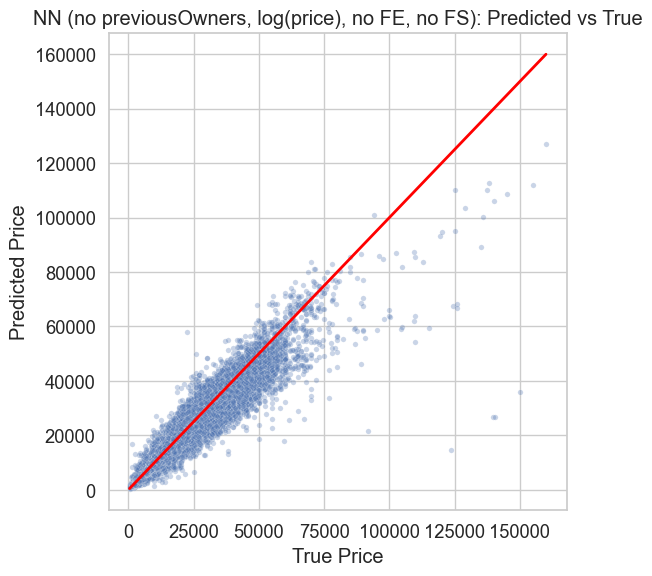

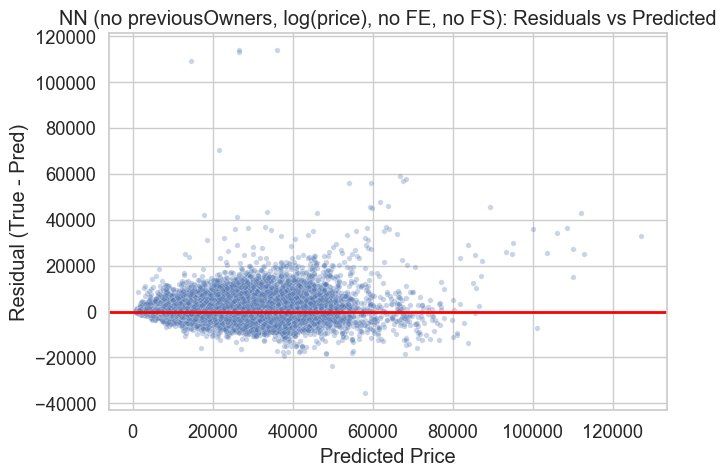

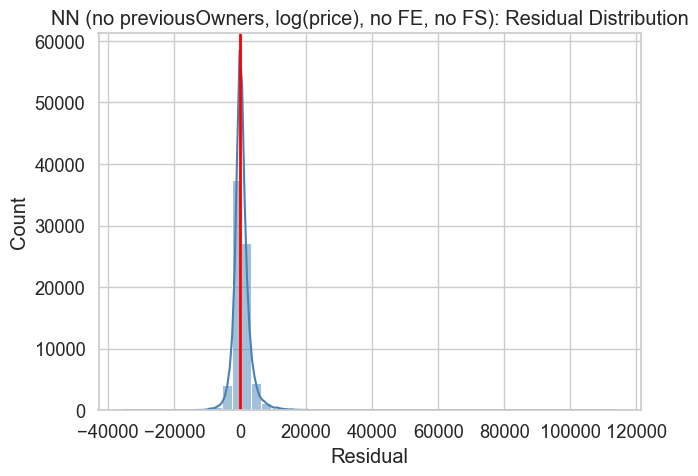

In [6]:
# -----------------------------
# 1) Best config (your chosen one)
# -----------------------------
params = {
    "hidden_layer_sizes": (256, 128),
    "learning_rate_init": 0.005,
    "activation": "relu",
    "solver": "adam",
    "batch_size": 64,
    "max_iter": 900,
    "learning_rate": "adaptive",
    "early_stopping": True,
    "n_iter_no_change": 25
}

MODEL_NAME = "NN (no previousOwners, log(price), no FE, no FS)"

# -----------------------------
# 2) Build FULL training matrix for this setting
#    (same logic as the CV loop, but fit on ALL data)
# -----------------------------
numeric_features = ["year", "mileage", "engineSize", "tax", "mpg"]  # previousOwners excluded
categorical_features = ["Brand", "model", "transmission", "fuelType"]

X_full = X.copy()
y_full = y.copy()

# ensure previousOwners never enters the pipeline
X_full = X_full.drop(columns=["previousOwners"], errors="ignore")

# log target (train in log-space)
y_full_log = np.log1p(y_full)

# ---- Preprocessing (fit on full data, transform on full data) ----
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full,
    valid_brands=valid_brands,
    brand_col="Brand",
    model_col="model",
    year_col="year",
)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(
    train_df=X_full,
    valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand",
    model_col="model",
    year_col="year",
    fuel_col="fuelType",
    mpg_col="mpg",
)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(
    train_df=X_full,
    valid_transmissions=valid_transmissions,
    transm_col="transmission",
    brand_col="Brand",
    model_col="model",
    fuel_col="fuelType",
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full,
    valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType",
    brand_col="Brand",
    model_col="model",
    transm_col="transmission",
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

# ---- Encoding (TE for Brand+model, OHE for the rest) ----
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_log)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

#------------------
# ---- Numeric + Target-encoded features ----
X_full_num_te = pd.concat([X_full[numeric_features], X_full_high], axis=1)

# Apply standard scaling
scaler = StandardScaler()
X_full_num_te_scaled = scaler.fit_transform(X_full_num_te)

# Turn it back into a DataFrame
X_full_num_te_scaled_df = pd.DataFrame(
    X_full_num_te_scaled,
    index=X_full.index,
    columns=X_full_num_te.columns
)

X_full_sel = pd.concat([X_full_num_te_scaled_df, X_full_low], axis=1)

# -----------------------------
# 3) Fit FINAL model on FULL data (log-space)
# -----------------------------
mlp_model = MLPRegressor(
    hidden_layer_sizes=params["hidden_layer_sizes"],
    activation=params.get("activation"),
    solver=params.get("solver"),
    learning_rate_init=params.get("learning_rate_init"),
    learning_rate=params.get("learning_rate"),
    batch_size=params.get("batch_size", "auto"),
    max_iter=params.get("max_iter"),
    n_iter_no_change=params.get("n_iter_no_change", 25),
    early_stopping=params.get("early_stopping"),
    random_state=42,
    verbose=False
)

print("- training nn (log-price)")
mlp_model.fit(X_full_sel, y_full_log)

# -----------------------------
# 4) Run ALL visualizations for this best model
# -----------------------------
plot_pred_vs_true_fs(mlp_model, MODEL_NAME)
plot_residuals_fs(mlp_model, MODEL_NAME)
plot_residual_distribution_fs(mlp_model, MODEL_NAME)

C:\Users\Rosa Melo\AppData\Local\Temp\ipykernel_31112\4128551160.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


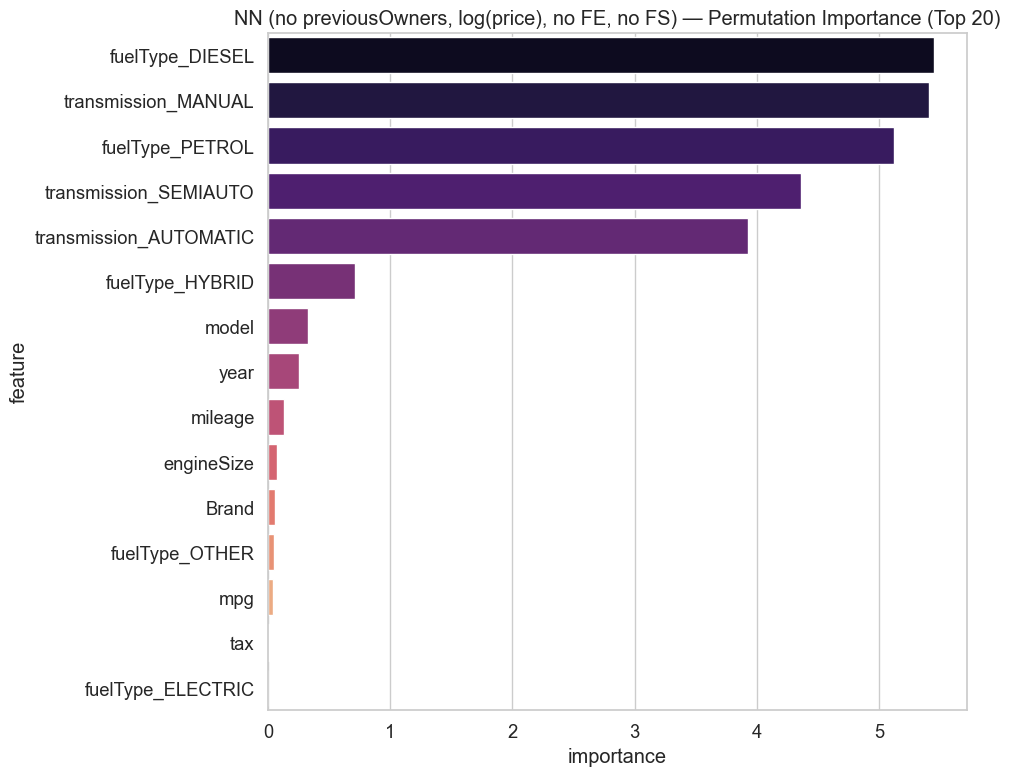

In [8]:
plot_permutation_importance_fs(mlp_model, MODEL_NAME, n_repeats=5, top=20)

In [11]:
apply_shap_fs(mlp_model, X_full_sel, model_name=MODEL_NAME, sample_size=2000)

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  6%|▌         | 111/2000 [04:41<1:19:53,  2.54s/it]


KeyboardInterrupt: 